In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv("online_shoppers_intention.csv")

# Basic info
print(df.head())
print(df.info())
print(df.describe())


   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.00       0.10         0.0         0.0   Feb   

In [9]:
df.isnull().sum()
df.drop_duplicates(inplace=True)


In [10]:
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)


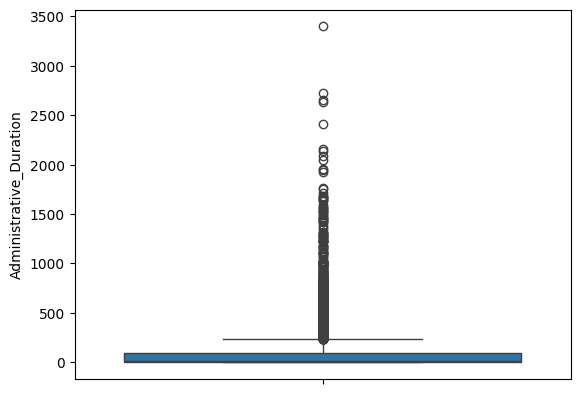

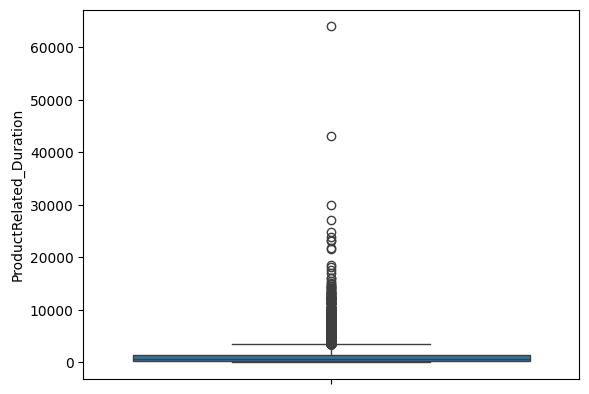

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(df['Administrative_Duration'])
plt.show()

sns.boxplot(df['ProductRelated_Duration'])
plt.show()


In [12]:
df_encoded = pd.get_dummies(df, 
                            columns=['Month', 'VisitorType'], 
                            drop_first=True)


In [13]:
num_cols = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay'
]



#use standard scaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])



In [14]:
#Split Data into Train & Test Sets

from sklearn.model_selection import train_test_split

X = df_encoded.drop('Revenue', axis=1)
y = df_encoded['Revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


In [15]:
df_encoded['EngagementScore'] = (
    df['Administrative'] + 
    df['Informational'] + 
    df['ProductRelated']
)

df_encoded['DurationScore'] = (
    df['Administrative_Duration'] + 
    df['Informational_Duration'] + 
    df['ProductRelated_Duration']
)

df_encoded['ExitMinusBounce'] = df['ExitRates'] - df['BounceRates']


In [16]:
df_encoded[['EngagementScore','DurationScore','ExitMinusBounce']] = scaler.fit_transform(
    df_encoded[['EngagementScore','DurationScore','ExitMinusBounce']]
)


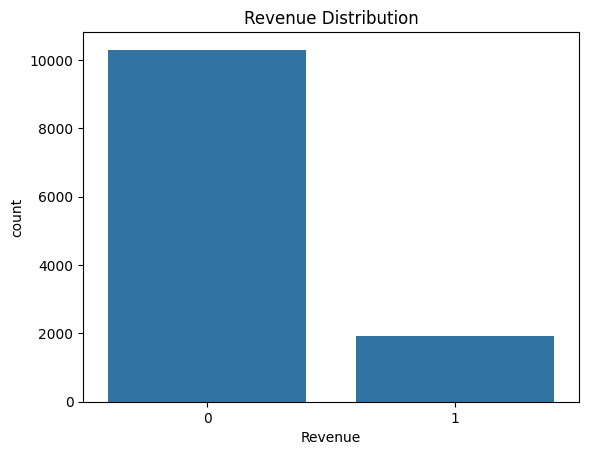

In [17]:
#Revenue distribution

sns.countplot(x='Revenue', data=df)
plt.title("Revenue Distribution")
plt.show()


In [18]:
month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4,
    'May': 5, 'June': 6, 'Jul': 7, 'Aug': 8,
    'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

df['MonthNumber'] = df['Month'].map(month_map)


In [19]:
df[['Month', 'MonthNumber']].head()


,Month,MonthNumber
0,Feb,2
1,Feb,2
2,Feb,2
3,Feb,2
4,Feb,2


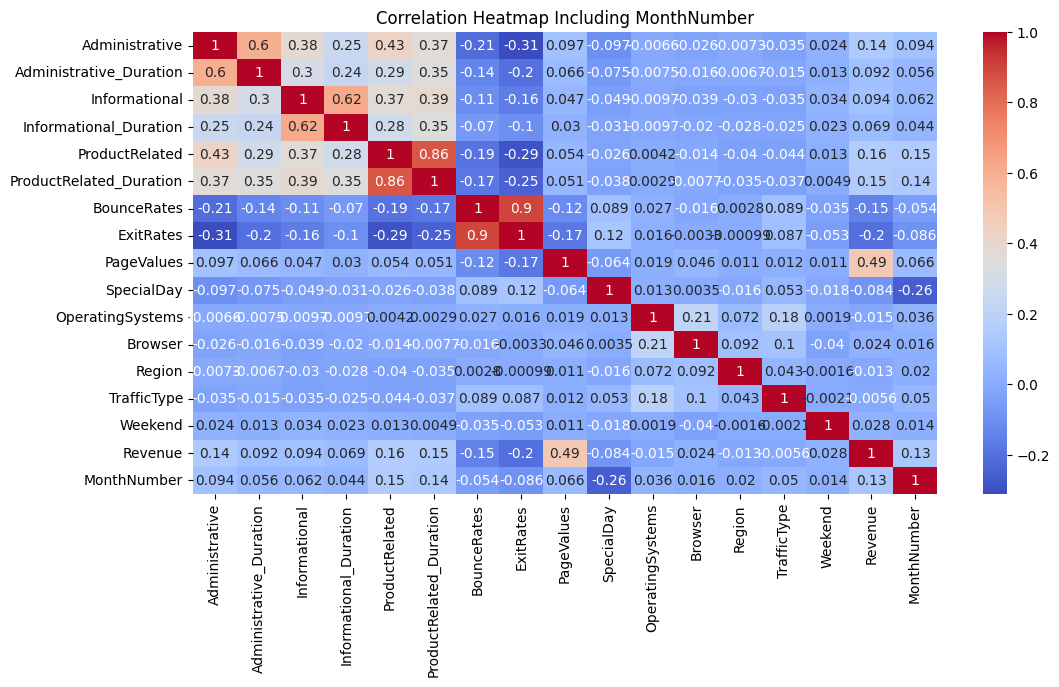

In [20]:
#Correlation Heatmap 
numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(12,6))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True)
plt.title("Correlation Heatmap Including MonthNumber")
plt.show()



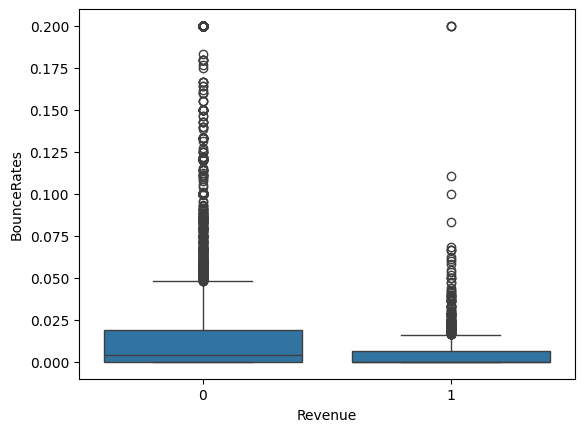

In [21]:
#Boxplot BounceRates vs Revenue

sns.boxplot(x='Revenue', y='BounceRates', data=df)
plt.show()


In [22]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_pred_lr_proba = log_reg.predict_proba(X_test)[:, 1]

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_lr_proba))
print(classification_report(y_test, y_pred_lr))



Logistic Regression Accuracy: 0.8892529488859764
ROC-AUC: 0.8964319879505812
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      2575
           1       0.77      0.41      0.54       477

    accuracy                           0.89      3052
   macro avg       0.84      0.70      0.74      3052
weighted avg       0.88      0.89      0.87      3052



/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linea

In [23]:
#Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.8997378768020969
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      2575
           1       0.71      0.60      0.65       477

    accuracy                           0.90      3052
   macro avg       0.82      0.78      0.80      3052
weighted avg       0.89      0.90      0.90      3052



In [24]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.8735255570117956
              precision    recall  f1-score   support

           0       0.89      0.96      0.93      2575
           1       0.66      0.39      0.49       477

    accuracy                           0.87      3052
   macro avg       0.78      0.67      0.71      3052
weighted avg       0.86      0.87      0.86      3052



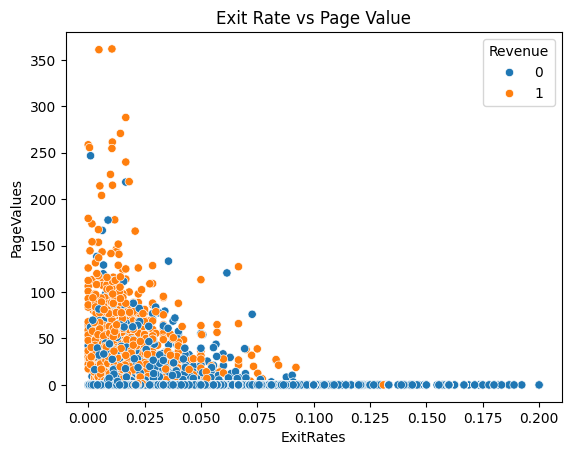

In [25]:
sns.scatterplot(x='ExitRates', y='PageValues', hue='Revenue', data=df)
plt.title("Exit Rate vs Page Value")
plt.show()


In [26]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Create SVM model with RBF kernel
svm_clf = SVC(kernel='rbf', probability=True, random_state=42)
svm_clf.fit(X_train, y_train)

# Predictions
y_pred_svm = svm_clf.predict(X_test)
y_pred_svm_proba = svm_clf.predict_proba(X_test)[:, 1]

# Evaluation
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_svm_proba))
print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.8902359108781127
ROC-AUC: 0.8783684435488796
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      2575
           1       0.76      0.43      0.55       477

    accuracy                           0.89      3052
   macro avg       0.83      0.70      0.74      3052
weighted avg       0.88      0.89      0.88      3052



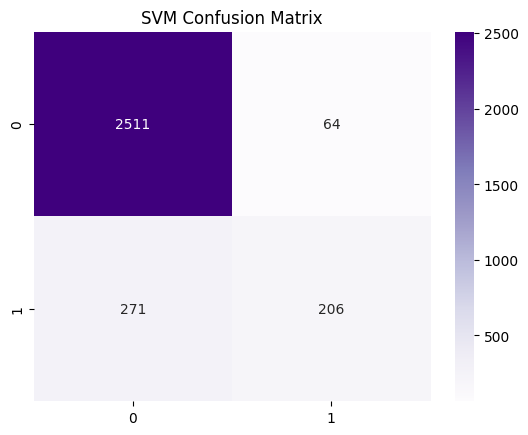

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("SVM Confusion Matrix")
plt.show()


In [28]:
# Model Performance Comparison

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "Logistic Regression": log_reg,
    "Decision Tree": dt,
    "KNN": knn,
    "SVM": svm_clf
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    # ROC-AUC requires probability scores or decision scores
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_score)
    })

model_results = pd.DataFrame(results)

model_results.sort_values(
    by="ROC-AUC",
    ascending=False
)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Decision Tree,0.899738,0.712159,0.601677,0.652273,0.922961
0,Logistic Regression,0.889253,0.772549,0.412998,0.538251,0.896432
3,SVM,0.890236,0.762963,0.431866,0.551539,0.878368
2,KNN,0.873526,0.664260,0.385744,0.488064,0.779306


In [29]:
# Feature Importance - Decision Tree

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": dt.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
8,PageValues,0.772082
6,BounceRates,0.077577
21,Month_Nov,0.045244
5,ProductRelated_Duration,0.039767
0,Administrative,0.023652
1,Administrative_Duration,0.010207
7,ExitRates,0.009075
19,Month_Mar,0.006445
25,VisitorType_Returning_Visitor,0.005831
17,Month_Jul,0.003212


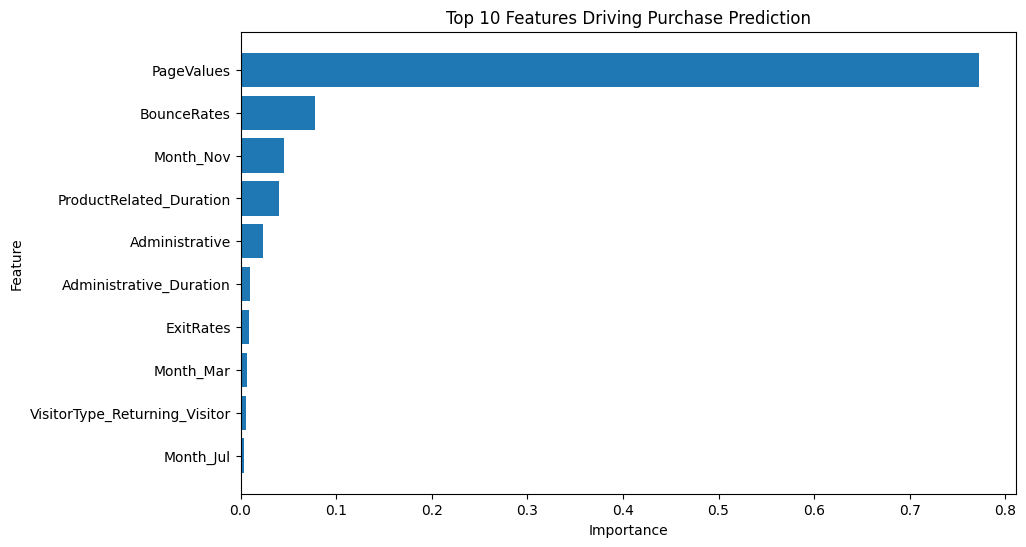

In [30]:
# Visualize Top 10 Important Features

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features Driving Purchase Prediction")
plt.show()

In [31]:
# Purchase Probability and High-Intent Session Segmentation

X_test_scored = X_test.copy()

X_test_scored["Actual_Revenue"] = y_test.values

X_test_scored["Purchase_Probability"] = dt.predict_proba(X_test)[:, 1]

X_test_scored["Intent_Segment"] = pd.cut(
    X_test_scored["Purchase_Probability"],
    bins=[0, 0.30, 0.60, 1.00],
    labels=["Low Intent", "Medium Intent", "High Intent"],
    include_lowest=True
)

X_test_scored[
    ["Purchase_Probability", "Intent_Segment", "Actual_Revenue"]
].head(10)

,Purchase_Probability,Intent_Segment,Actual_Revenue
4329,0.575610,Medium Intent,0
9891,0.016100,Low Intent,0
3180,0.001213,Low Intent,0
11015,0.016100,Low Intent,0
586,0.024805,Low Intent,0
11912,0.785714,High Intent,1
4132,0.024805,Low Intent,0
8588,0.054054,Low Intent,0
9050,0.054054,Low Intent,0
3071,0.024805,Low Intent,0


In [32]:
# Intent Segment Summary

intent_summary = (
    X_test_scored
    .groupby("Intent_Segment", observed=True)
    .agg(
        Sessions=("Actual_Revenue", "count"),
        Purchases=("Actual_Revenue", "sum"),
        Avg_Purchase_Probability=("Purchase_Probability", "mean")
    )
    .reset_index()
)

intent_summary["Conversion_Rate"] = (
    intent_summary["Purchases"] /
    intent_summary["Sessions"] * 100
).round(2)

intent_summary

,Intent_Segment,Sessions,Purchases,Avg_Purchase_Probability,Conversion_Rate
0,Low Intent,2542,137,0.052279,5.39
1,Medium Intent,234,129,0.497471,55.13
2,High Intent,276,211,0.847187,76.45


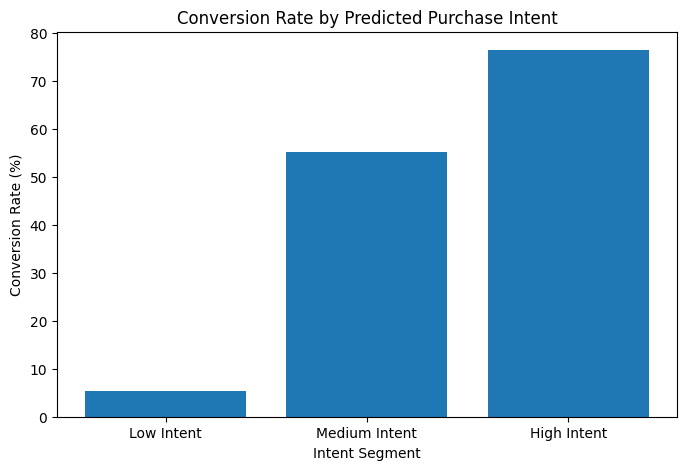

In [33]:
# Visualize Conversion Rate by Intent Segment

plt.figure(figsize=(8, 5))

plt.bar(
    intent_summary["Intent_Segment"].astype(str),
    intent_summary["Conversion_Rate"]
)

plt.xlabel("Intent Segment")
plt.ylabel("Conversion Rate (%)")
plt.title("Conversion Rate by Predicted Purchase Intent")
plt.show()